# 9주차: CNN 기초 (Convolutional Neural Network)

**딥러닝 입문** | 9주차

---

## 이번 주 학습 목표

1. CNN 핵심 용어(필터, 채널, feature map, 패딩, 스트라이드, 풀링) 직관적 이해
2. Convolution 연산의 동작 방식
3. Feature map 크기와 파라미터 수 계산
4. PyTorch로 기본 CNN 구현
5. CIFAR-10 데이터셋으로 실습

---

## 지난 주까지 돌아보기

8주차까지 우리는 **완전연결 신경망(Fully Connected Network, FC)** 을 배웠습니다. FC 네트워크는 모든 입력 뉴런과 출력 뉴런이 연결되어 있어서 표 형태의 데이터에는 잘 작동했습니다.

그런데 이미지 데이터에 FC를 그대로 적용하면 어떤 문제가 생길까요?

예를 들어, **32×32 RGB 이미지** 하나의 픽셀 수는:
$$32 \times 32 \times 3 = 3072$$

첫 번째 은닉층에 뉴런이 512개라면, 이 층의 파라미터 수만:
$$3072 \times 512 + 512 = 1,573,376 \approx 157만 개$$

이미지가 커질수록 파라미터 수가 폭발적으로 늘어납니다. 더 큰 문제는, FC는 **공간 구조**를 전혀 활용하지 못합니다. 이미지의 픽셀들을 그냥 1D 벡터로 펼쳐버리기 때문에, "근처 픽셀끼리 관련이 높다"는 사실을 무시합니다.

이 문제를 해결하기 위해 등장한 것이 **CNN(Convolutional Neural Network)**  입니다.

---

# 섹션 0 — CNN 핵심 개념 사전 (용어 & 직관)

> 이 섹션은 영상 강의에서 자세히 다룹니다. 처음 보는 용어가 많더라도 걱정하지 마세요.  
> 아래 시각화들을 직접 실행하면서 "아, 이런 거구나" 하는 느낌을 먼저 잡는 것이 목표입니다.

---

## 0-1. 이미지는 숫자 배열이다

컴퓨터에게 이미지는 단순한 **숫자 배열**입니다.

- **흑백(Grayscale) 이미지**: 각 픽셀이 0(검정)~255(흰색) 사이의 숫자 하나. shape = `(H, W)`
- **컬러(RGB) 이미지**: 각 픽셀이 Red, Green, Blue 세 숫자. shape = `(H, W, 3)` 또는 PyTorch에서 `(3, H, W)`

CNN은 이 숫자 배열에서 패턴을 찾아내는 방법입니다.

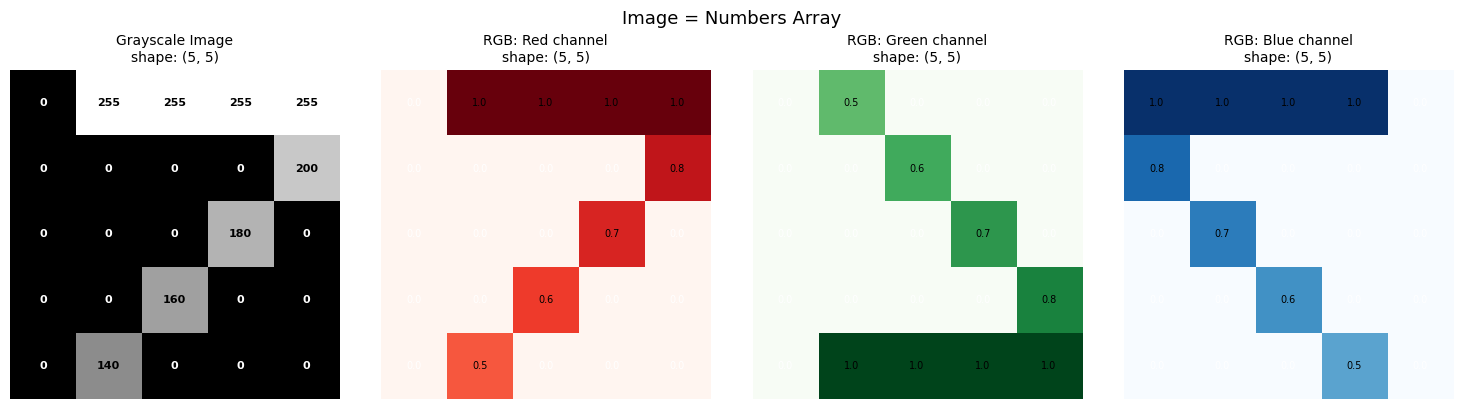

Grayscale shape : (5, 5)
RGB shape       : (5, 5, 3)  →  PyTorch: (3, 5, 5)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)

# ── 5x5 grayscale image (hand-drawn digit "7") ──
img_gray = np.array([
    [0, 255, 255, 255, 255],
    [0,   0,   0,   0, 200],
    [0,   0,   0, 180,   0],
    [0,   0, 160,   0,   0],
    [0, 140,   0,   0,   0],
], dtype=np.float32)

# ── 5x5 RGB image (random colorful patch) ──
img_rgb = np.zeros((5, 5, 3), dtype=np.float32)
img_rgb[:, :, 0] = img_gray / 255.0          # Red channel
img_rgb[:, :, 1] = np.flipud(img_gray) / 255.0  # Green channel
img_rgb[:, :, 2] = np.fliplr(img_gray) / 255.0  # Blue channel

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('Image = Numbers Array', fontsize=13, y=1.01)

# Grayscale image
axes[0].imshow(img_gray, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Grayscale Image\nshape: (5, 5)', fontsize=10)
for i in range(5):
    for j in range(5):
        val = int(img_gray[i, j])
        color = 'white' if val < 128 else 'black'
        axes[0].text(j, i, str(val), ha='center', va='center',
                     color=color, fontsize=8, fontweight='bold')
axes[0].axis('off')

# RGB channels
channel_names = ['Red channel', 'Green channel', 'Blue channel']
cmaps = ['Reds', 'Greens', 'Blues']
for c, (name, cmap) in enumerate(zip(channel_names, cmaps)):
    axes[c+1].imshow(img_rgb[:, :, c], cmap=cmap, vmin=0, vmax=1)
    axes[c+1].set_title(f'RGB: {name}\nshape: (5, 5)', fontsize=10)
    for i in range(5):
        for j in range(5):
            val = img_rgb[i, j, c]
            color = 'white' if val < 0.5 else 'black'
            axes[c+1].text(j, i, f'{val:.1f}', ha='center', va='center',
                           color=color, fontsize=7)
    axes[c+1].axis('off')

plt.tight_layout()
plt.show()
print(f"Grayscale shape : {img_gray.shape}")
print(f"RGB shape       : {img_rgb.shape}  →  PyTorch: (3, 5, 5)")

---

## 0-2. 필터(Filter / Kernel) — 특징을 찾아내는 탐지기

**필터**는 이미지에서 특정 패턴을 찾아내는 작은 숫자 배열입니다. 보통 3×3 또는 5×5 크기를 씁니다.

필터는 이렇게 작동합니다:
1. 필터를 이미지 위 한 위치에 올려놓는다
2. 겹치는 숫자끼리 곱하고 전부 더한다 (= **점곱, dot product**)
3. 필터를 한 칸 옆으로 옮기고 반복한다
4. 모든 위치를 훑으면 **Feature Map**이 완성된다

필터의 값이 찾으려는 패턴과 비슷할수록 결과값이 크게 나옵니다.  
즉, **결과값 크기 = "이 위치에 이 패턴이 얼마나 있는가"**

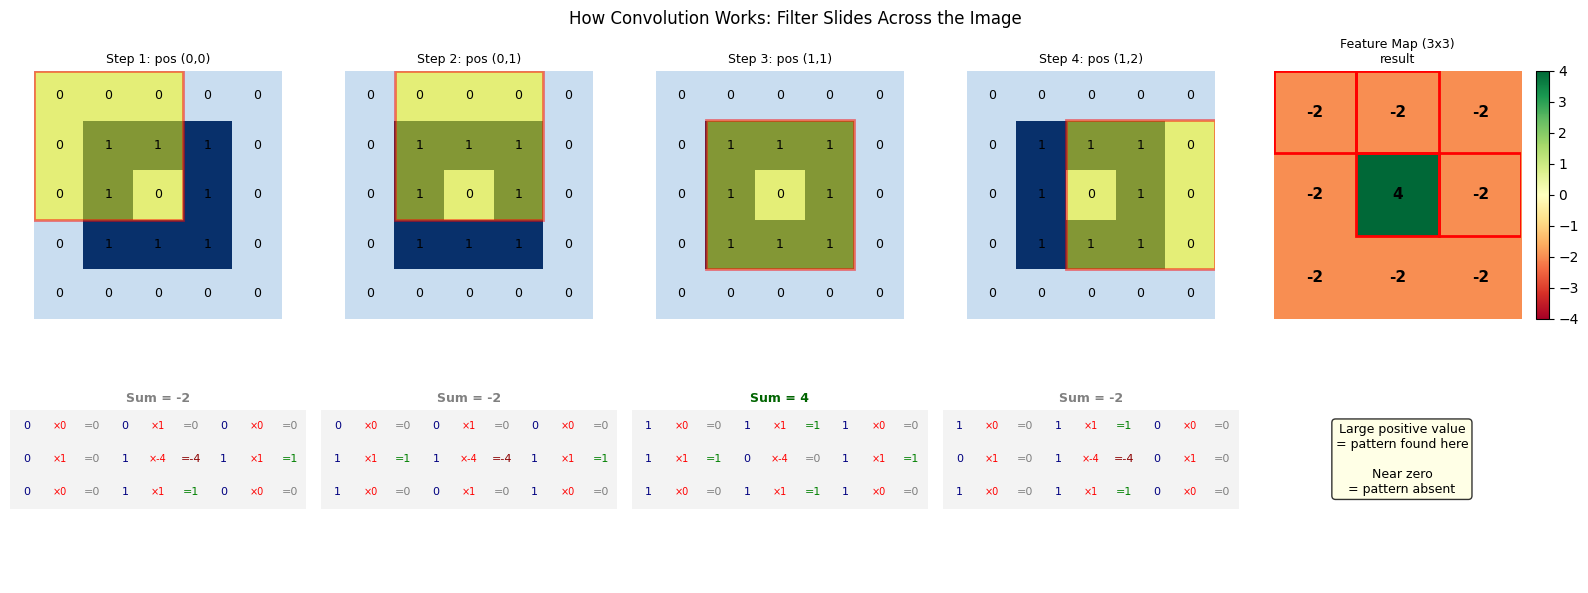

In [2]:
# ── Convolution step-by-step animation ──
# Show exactly what happens at each filter position

image_5x5 = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 1, 0, 1, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0],
], dtype=float)  # a ring shape

# Ring-detector filter (responds strongly to ring-like pattern)
kernel = np.array([
    [0,  1,  0],
    [1, -4,  1],
    [0,  1,  0],
], dtype=float)

# Compute full feature map
def conv2d_manual(img, k):
    H, W = img.shape
    kH, kW = k.shape
    oH, oW = H - kH + 1, W - kW + 1
    out = np.zeros((oH, oW))
    for i in range(oH):
        for j in range(oW):
            out[i, j] = np.sum(img[i:i+kH, j:j+kW] * k)
    return out

feat_map = conv2d_manual(image_5x5, kernel)

# Show 4 specific positions to illustrate the sliding
positions = [(0,0), (0,1), (1,1), (1,2)]

fig, axes = plt.subplots(2, len(positions)+1, figsize=(16, 6))
fig.suptitle('How Convolution Works: Filter Slides Across the Image', fontsize=12)

for col, (pi, pj) in enumerate(positions):
    # Top row: image with filter position highlighted
    ax_img = axes[0, col]
    ax_img.imshow(image_5x5, cmap='Blues', vmin=-0.3, vmax=1)
    for i in range(5):
        for j in range(5):
            ax_img.text(j, i, str(int(image_5x5[i,j])),
                        ha='center', va='center', fontsize=9)
    # Highlight filter window
    rect = plt.Rectangle((pj-0.5, pi-0.5), 3, 3,
                          fill=True, facecolor='yellow', alpha=0.5,
                          edgecolor='red', linewidth=2)
    ax_img.add_patch(rect)
    ax_img.set_title(f'Step {col+1}: pos ({pi},{pj})', fontsize=9)
    ax_img.axis('off')

    # Bottom row: computation detail
    ax_calc = axes[1, col]
    patch = image_5x5[pi:pi+3, pj:pj+3]
    product = patch * kernel
    result = product.sum()
    # Show patch * kernel = products table
    display = np.zeros((3, 9))
    for r in range(3):
        for c in range(3):
            display[r, c*3] = patch[r, c]
            display[r, c*3+1] = kernel[r, c]
            display[r, c*3+2] = product[r, c]
    ax_calc.imshow(np.ones((3, 9)) * 0.95, cmap='gray', vmin=0, vmax=1)
    for r in range(3):
        for c in range(3):
            p_val = int(patch[r, c])
            k_val = int(kernel[r, c])
            pr_val = int(product[r, c])
            ax_calc.text(c*3+0, r, str(p_val), ha='center', va='center', fontsize=8, color='navy')
            ax_calc.text(c*3+1, r, f'×{k_val}', ha='center', va='center', fontsize=7, color='red')
            ax_calc.text(c*3+2, r, f'={pr_val}', ha='center', va='center', fontsize=8,
                         color='green' if pr_val > 0 else ('gray' if pr_val == 0 else 'darkred'))
    ax_calc.set_title(f'Sum = {int(result)}', fontsize=9, fontweight='bold',
                      color='darkgreen' if result > 0 else 'gray')
    ax_calc.axis('off')

# Last column: show the resulting feature map
ax_fm = axes[0, -1]
im = ax_fm.imshow(feat_map, cmap='RdYlGn', vmin=-4, vmax=4)
for i in range(3):
    for j in range(3):
        ax_fm.text(j, i, str(int(feat_map[i,j])),
                   ha='center', va='center', fontsize=11, fontweight='bold')
# Highlight the computed positions
for col, (pi, pj) in enumerate(positions):
    rect2 = plt.Rectangle((pj-0.5, pi-0.5), 1, 1,
                           fill=False, edgecolor='red', linewidth=2)
    ax_fm.add_patch(rect2)
ax_fm.set_title('Feature Map (3x3)\nresult', fontsize=9)
ax_fm.axis('off')
plt.colorbar(im, ax=ax_fm, fraction=0.046)

axes[1, -1].text(0.5, 0.5,
    'Large positive value\n= pattern found here\n\nNear zero\n= pattern absent',
    ha='center', va='center', fontsize=9,
    transform=axes[1, -1].transAxes,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, -1].axis('off')

plt.tight_layout()
plt.show()

---

## 0-3. 채널(Channel) — 여러 각도로 동시에 보기

**채널**은 "같은 공간을 바라보는 서로 다른 관점"입니다.

- **입력 이미지**: RGB 3채널 → 빨강/초록/파랑 세 가지 시각으로 이미지를 봄
- **Convolution 후**: 필터 개수 = 출력 채널 수. 필터가 32개면 32가지 특징을 동시에 탐지

각 필터는 독립적으로 학습되어 서로 다른 특징을 검출합니다.
얕은 층에서는 엣지·색상 같은 단순 특징을, 깊은 층에서는 눈·바퀴 같은 복잡한 패턴을 담게 됩니다.

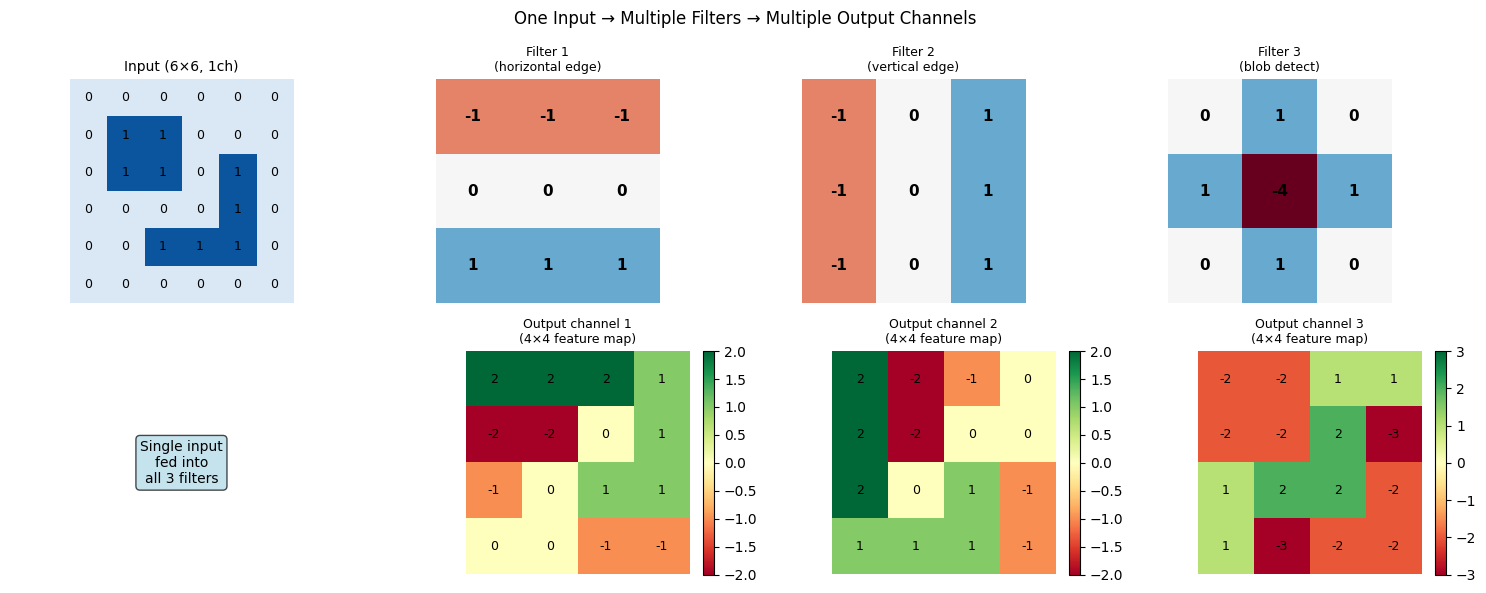

입력: 1채널(6×6)  →  필터 3개  →  출력: 3채널(4×4)
실제 CNN: 입력 3채널(RGB), 필터 32~512개 → 출력 32~512채널


In [3]:
# ── Channel concept: one input → multiple filters → multiple output channels ──

# A simple 6x6 grayscale-ish input with clear structure
inp = np.array([
    [0,0,0,0,0,0],
    [0,1,1,0,0,0],
    [0,1,1,0,1,0],
    [0,0,0,0,1,0],
    [0,0,1,1,1,0],
    [0,0,0,0,0,0],
], dtype=float)

# Three different filters detecting different patterns
filters = {
    'Filter 1\n(horizontal edge)': np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=float),
    'Filter 2\n(vertical edge)':   np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=float),
    'Filter 3\n(blob detect)':     np.array([[0,1,0],[1,-4,1],[0,1,0]], dtype=float),
}

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
fig.suptitle('One Input → Multiple Filters → Multiple Output Channels', fontsize=12)

# Input
axes[0, 0].imshow(inp, cmap='Blues', vmin=-0.2, vmax=1.2)
for i in range(6):
    for j in range(6):
        axes[0, 0].text(j, i, str(int(inp[i,j])),
                         ha='center', va='center', fontsize=9)
axes[0, 0].set_title('Input (6×6, 1ch)', fontsize=10)
axes[0, 0].axis('off')
axes[1, 0].text(0.5, 0.5, 'Single input\nfed into\nall 3 filters',
                ha='center', va='center', fontsize=10,
                transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
axes[1, 0].axis('off')

# Each filter and its feature map
for col, (fname, filt) in enumerate(filters.items()):
    fmap = conv2d_manual(inp, filt)

    # Top: filter values
    ax_f = axes[0, col+1]
    ax_f.imshow(filt, cmap='RdBu', vmin=-2, vmax=2)
    for i in range(3):
        for j in range(3):
            ax_f.text(j, i, str(int(filt[i,j])),
                      ha='center', va='center', fontsize=11, fontweight='bold')
    ax_f.set_title(fname, fontsize=9)
    ax_f.axis('off')

    # Bottom: resulting feature map
    ax_m = axes[1, col+1]
    vmax = max(abs(fmap.max()), abs(fmap.min()), 1)
    im = ax_m.imshow(fmap, cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    for i in range(fmap.shape[0]):
        for j in range(fmap.shape[1]):
            ax_m.text(j, i, str(int(fmap[i,j])),
                      ha='center', va='center', fontsize=9)
    ax_m.set_title(f'Output channel {col+1}\n(4×4 feature map)', fontsize=9)
    ax_m.axis('off')
    plt.colorbar(im, ax=ax_m, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
print("입력: 1채널(6×6)  →  필터 3개  →  출력: 3채널(4×4)")
print("실제 CNN: 입력 3채널(RGB), 필터 32~512개 → 출력 32~512채널")

---

## 0-4. Feature Map — 필터의 응답 지도

**Feature Map**은 필터 하나를 이미지 전체에 적용한 결과물입니다.

- Feature map의 각 위치 값 = "이 위치에 이 패턴이 얼마나 강하게 있는가"
- 값이 클수록 해당 위치에서 필터가 감지하려는 패턴이 뚜렷함
- Conv 층의 출력 채널 수 = feature map의 개수

> **비유**: 필터는 "엣지 탐지 안경", feature map은 "그 안경을 끼고 본 이미지"

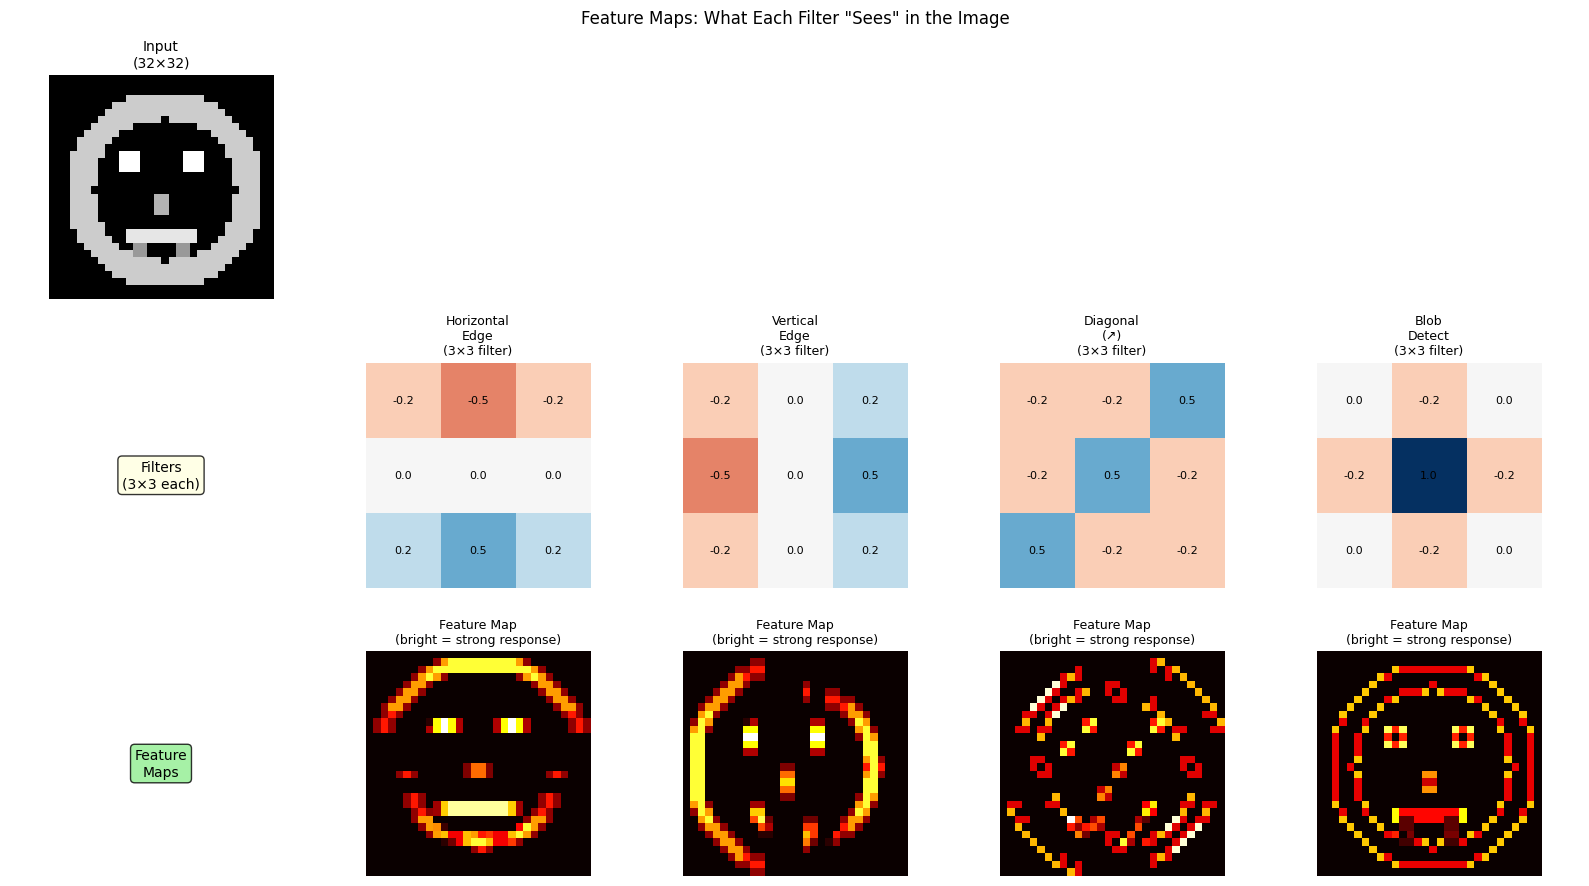

In [4]:
# ── Real image → real learned filters → what feature maps look like ──
# Use a synthetic "face-like" image to show intuitive feature maps

# Synthetic face-like image (32x32)
face = np.zeros((32, 32), dtype=np.float32)
# Face outline
for i in range(32):
    for j in range(32):
        cx, cy = 16, 16
        r = np.sqrt((i-cy)**2 + (j-cx)**2)
        if 10 < r < 14:
            face[i,j] = 0.8
# Eyes
face[11:14, 10:13] = 1.0
face[11:14, 19:22] = 1.0
# Nose
face[17:20, 15:17] = 0.7
# Mouth
face[22:24, 11:21] = 0.9
face[24:26, 12:14] = 0.6
face[24:26, 18:20] = 0.6

# Hand-crafted filters with intuitive meaning
named_filters = [
    ('Horizontal\nEdge', np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=np.float32) / 4),
    ('Vertical\nEdge',   np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=np.float32) / 4),
    ('Diagonal\n(↗)',    np.array([[-1,-1,2],[-1,2,-1],[2,-1,-1]], dtype=np.float32) / 4),
    ('Blob\nDetect',     np.array([[0,-1,0],[-1,4,-1],[0,-1,0]], dtype=np.float32) / 4),
]

fig, axes = plt.subplots(3, len(named_filters)+1, figsize=(16, 9))
fig.suptitle('Feature Maps: What Each Filter "Sees" in the Image', fontsize=12)

# Row 0: input
axes[0, 0].imshow(face, cmap='gray')
axes[0, 0].set_title('Input\n(32×32)', fontsize=10)
axes[0, 0].axis('off')
for ax in axes[0, 1:]:
    ax.axis('off')

# Row 1: filters, Row 2: feature maps
for col, (fname, filt) in enumerate(named_filters):
    # Filter visualization
    ax_f = axes[1, col+1]
    ax_f.imshow(filt, cmap='RdBu', vmin=-1, vmax=1)
    for i in range(3):
        for j in range(3):
            ax_f.text(j, i, f'{filt[i,j]:.1f}',
                      ha='center', va='center', fontsize=8)
    ax_f.set_title(f'{fname}\n(3×3 filter)', fontsize=9)
    ax_f.axis('off')

    # Feature map
    fmap = conv2d_manual(face, filt)
    ax_m = axes[2, col+1]
    vmax = np.abs(fmap).max() + 1e-6
    ax_m.imshow(fmap, cmap='hot', vmin=0, vmax=vmax)
    ax_m.set_title(f'Feature Map\n(bright = strong response)', fontsize=9)
    ax_m.axis('off')

# Side labels
axes[1, 0].text(0.5, 0.5, 'Filters\n(3×3 each)',
                ha='center', va='center', fontsize=10,
                transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1, 0].axis('off')
axes[2, 0].text(0.5, 0.5, 'Feature\nMaps',
                ha='center', va='center', fontsize=10,
                transform=axes[2, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
axes[2, 0].axis('off')

plt.tight_layout()
plt.show()

---

## 0-5. 패딩(Padding) — 가장자리를 지키는 방법

3×3 필터를 패딩 없이 적용하면 출력이 입력보다 **2픽셀씩 작아집니다** (각 방향 1픽셀 손실).  
층을 여러 개 쌓으면 가장자리 정보가 계속 사라집니다.

**Padding = 1** 은 이미지 경계에 0을 한 줄 덧댑니다. 그러면:
- 입력과 출력 크기가 동일하게 유지됨
- 가장자리 픽셀도 필터 중심에 올 수 있음

$$\text{output size} = \frac{H + 2 \times P - F}{S} + 1$$

패딩=1, 필터=3, 스트라이드=1 → $\frac{H + 2 - 3}{1} + 1 = H$ ✓

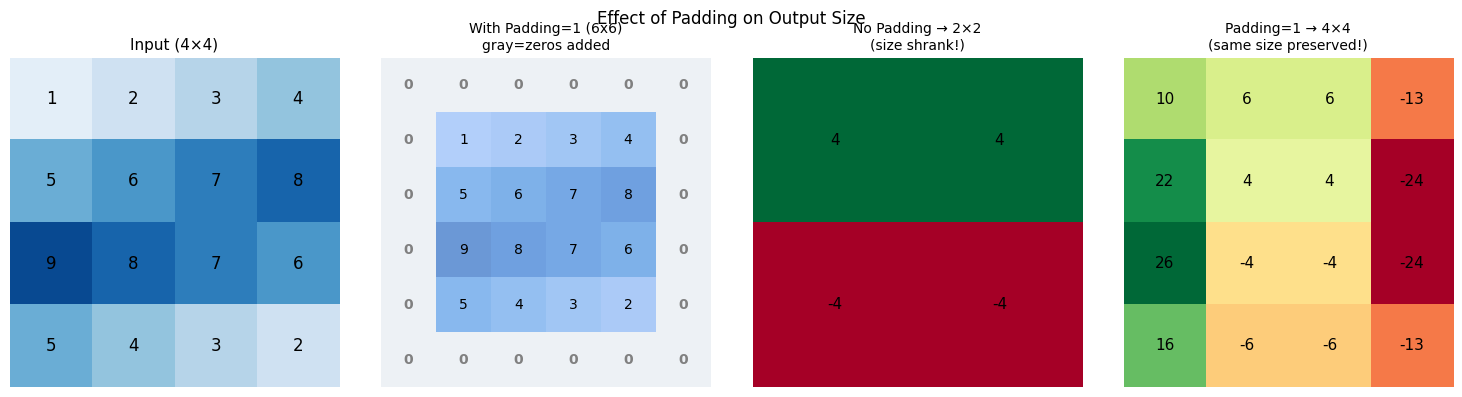

In [5]:
# ── Padding visualization: zero-pad then convolve ──

img_4x4 = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 8, 7, 6],
    [5, 4, 3, 2],
], dtype=float)

# Zero-pad with padding=1
img_padded = np.pad(img_4x4, pad_width=1, mode='constant', constant_values=0)

edge_filter = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)

out_no_pad = conv2d_manual(img_4x4, edge_filter)
out_padded = conv2d_manual(img_padded, edge_filter)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('Effect of Padding on Output Size', fontsize=12)

# Original
axes[0].imshow(img_4x4, cmap='Blues', vmin=0, vmax=10)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(int(img_4x4[i,j])),
                     ha='center', va='center', fontsize=12)
axes[0].set_title('Input (4×4)', fontsize=11)
axes[0].axis('off')

# Padded
mask = np.zeros_like(img_padded)
mask[1:5, 1:5] = 1  # original region
axes[1].imshow(img_padded, cmap='Blues', vmin=-1, vmax=10, alpha=0.5)
# Overlay to distinguish padding
pad_vis = np.ones((6,6,4))
pad_vis[:,:] = [0.9, 0.9, 0.9, 0.3]   # gray for padding
pad_vis[1:5, 1:5] = [0.2, 0.5, 1.0, 0.3]  # blue for original
axes[1].imshow(pad_vis)
for i in range(6):
    for j in range(6):
        val = int(img_padded[i,j])
        color = 'gray' if (i==0 or i==5 or j==0 or j==5) else 'black'
        axes[1].text(j, i, str(val), ha='center', va='center',
                     fontsize=10, color=color,
                     fontweight='bold' if color=='gray' else 'normal')
axes[1].set_title('With Padding=1 (6x6)\ngray=zeros added', fontsize=10)
axes[1].axis('off')

# Output without padding
axes[2].imshow(out_no_pad, cmap='RdYlGn')
for i in range(out_no_pad.shape[0]):
    for j in range(out_no_pad.shape[1]):
        axes[2].text(j, i, str(int(out_no_pad[i,j])),
                     ha='center', va='center', fontsize=11)
axes[2].set_title(f'No Padding → {out_no_pad.shape[0]}×{out_no_pad.shape[1]}\n(size shrank!)', fontsize=10)
axes[2].axis('off')

# Output with padding
axes[3].imshow(out_padded, cmap='RdYlGn')
for i in range(out_padded.shape[0]):
    for j in range(out_padded.shape[1]):
        axes[3].text(j, i, str(int(out_padded[i,j])),
                     ha='center', va='center', fontsize=11)
axes[3].set_title(f'Padding=1 → {out_padded.shape[0]}×{out_padded.shape[1]}\n(same size preserved!)', fontsize=10)
axes[3].axis('off')

plt.tight_layout()
plt.show()

---

## 0-6. 스트라이드(Stride) — 필터를 얼마나 건너뛰며 이동할까

지금까지는 필터를 한 칸씩 이동했습니다(stride=1). **스트라이드**는 한 번에 몇 칸씩 이동할지를 결정합니다.

- **stride=1**: 한 칸씩 이동 → 출력 크기 유지
- **stride=2**: 두 칸씩 이동 → 출력 크기 약 절반

스트라이드가 크면 계산량이 줄고 feature map이 작아집니다. 일종의 다운샘플링 효과가 생깁니다.

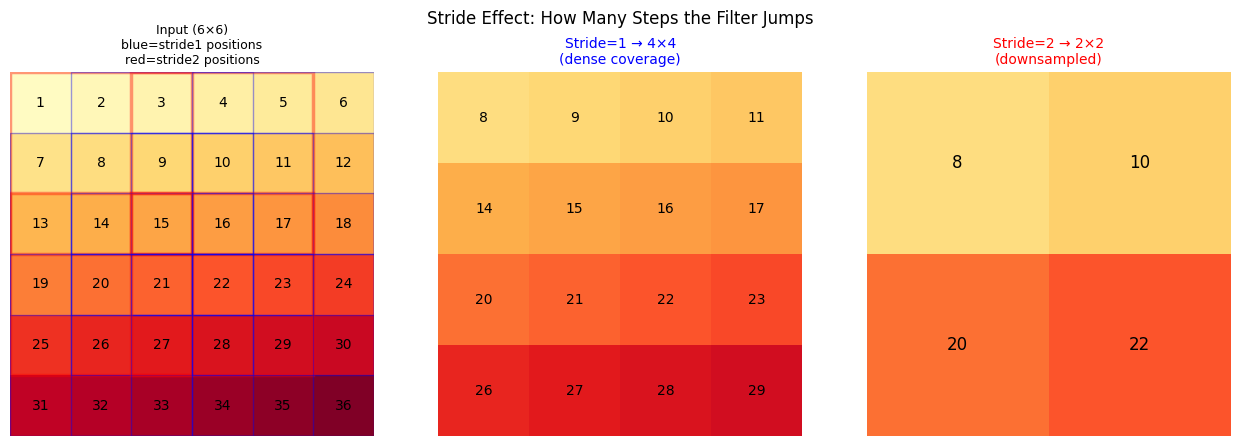

Stride=1: output (4, 4)
Stride=2: output (2, 2)  (roughly half the size)


In [6]:
# ── Stride visualization: stride=1 vs stride=2 ──

def conv2d_stride(img, k, stride=1):
    H, W = img.shape
    kH, kW = k.shape
    oH = (H - kH) // stride + 1
    oW = (W - kW) // stride + 1
    out = np.zeros((oH, oW))
    for i in range(oH):
        for j in range(oW):
            out[i,j] = np.sum(img[i*stride:i*stride+kH, j*stride:j*stride+kW] * k)
    return out

img_6x6 = np.arange(1, 37, dtype=float).reshape(6, 6)
filt_33 = np.ones((3, 3)) / 9.0  # averaging filter

out_s1 = conv2d_stride(img_6x6, filt_33, stride=1)
out_s2 = conv2d_stride(img_6x6, filt_33, stride=2)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Stride Effect: How Many Steps the Filter Jumps', fontsize=12)

# Input
axes[0].imshow(img_6x6, cmap='YlOrRd', vmin=0, vmax=36)
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, str(int(img_6x6[i,j])),
                     ha='center', va='center', fontsize=10)
# Show stride=1 positions (blue) and stride=2 positions (red)
for i in range(0, 4, 1):
    for j in range(0, 4, 1):
        if i % 2 == 0 and j % 2 == 0:
            c = 'red'
            lw = 2.5
        else:
            c = 'blue'
            lw = 1
        rect = plt.Rectangle((j-0.5, i-0.5), 3, 3,
                              fill=False, edgecolor=c, linewidth=lw, alpha=0.4)
        axes[0].add_patch(rect)
axes[0].set_title('Input (6×6)\nblue=stride1 positions\nred=stride2 positions', fontsize=9)
axes[0].axis('off')

# stride=1 output
axes[1].imshow(out_s1, cmap='YlOrRd', vmin=0, vmax=36)
for i in range(out_s1.shape[0]):
    for j in range(out_s1.shape[1]):
        axes[1].text(j, i, f'{out_s1[i,j]:.0f}',
                     ha='center', va='center', fontsize=10)
axes[1].set_title(f'Stride=1 → {out_s1.shape[0]}×{out_s1.shape[1]}\n(dense coverage)', fontsize=10,
                   color='blue')
axes[1].axis('off')

# stride=2 output
axes[2].imshow(out_s2, cmap='YlOrRd', vmin=0, vmax=36)
for i in range(out_s2.shape[0]):
    for j in range(out_s2.shape[1]):
        axes[2].text(j, i, f'{out_s2[i,j]:.0f}',
                     ha='center', va='center', fontsize=12)
axes[2].set_title(f'Stride=2 → {out_s2.shape[0]}×{out_s2.shape[1]}\n(downsampled)', fontsize=10,
                   color='red')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f"Stride=1: output {out_s1.shape}")
print(f"Stride=2: output {out_s2.shape}  (roughly half the size)")

---

## 0-7. 풀링(Pooling) — 요약하고 압축하기

Convolution 후 feature map은 여전히 큽니다. **Pooling**은 feature map을 작게 줄이는 연산입니다.

가장 많이 쓰이는 **Max Pooling**:
- 2×2 영역을 보면서 가장 큰 값 하나만 남김
- stride=2로 이동 → 크기가 절반으로
- "이 영역에 이 패턴이 있는가?" 를 압축해서 표현

**왜 최댓값?** 특징이 존재하는지를 판단할 때 "얼마나 강하게 반응했는가"의 최댓값이 가장 중요한 정보이기 때문입니다.

중요한 점: **Pooling에는 학습 파라미터가 없습니다.** 그냥 최댓값을 고르는 고정 연산입니다.

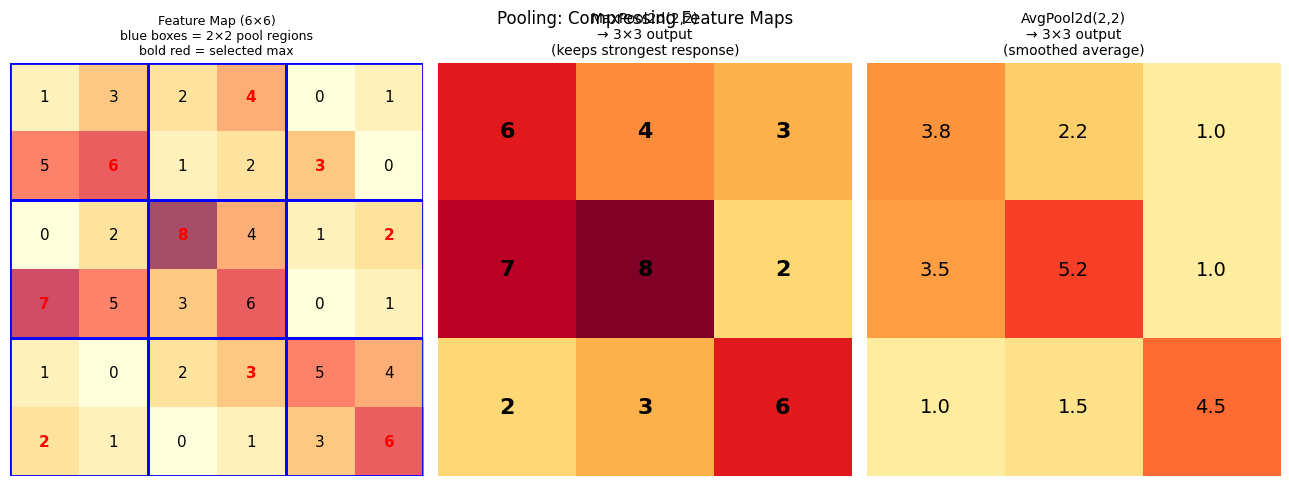

MaxPool: 특징의 존재 여부(최댓값) → CNN에서 주로 사용
AvgPool: 부드러운 평균 → Global Average Pooling 등 특수 용도


In [7]:
# ── MaxPooling step-by-step + comparison with AvgPool ──

feat = np.array([
    [ 1,  3,  2,  4,  0,  1],
    [ 5,  6,  1,  2,  3,  0],
    [ 0,  2,  8,  4,  1,  2],
    [ 7,  5,  3,  6,  0,  1],
    [ 1,  0,  2,  3,  5,  4],
    [ 2,  1,  0,  1,  3,  6],
], dtype=float)

# Max and Avg pool
def maxpool2d(x, size=2, stride=2):
    H, W = x.shape
    oH, oW = H//stride, W//stride
    out = np.zeros((oH, oW))
    for i in range(oH):
        for j in range(oW):
            out[i,j] = x[i*stride:i*stride+size, j*stride:j*stride+size].max()
    return out

def avgpool2d(x, size=2, stride=2):
    H, W = x.shape
    oH, oW = H//stride, W//stride
    out = np.zeros((oH, oW))
    for i in range(oH):
        for j in range(oW):
            out[i,j] = x[i*stride:i*stride+size, j*stride:j*stride+size].mean()
    return out

mp = maxpool2d(feat)
ap = avgpool2d(feat)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Pooling: Compressing Feature Maps', fontsize=12)

# Input feature map with pool regions highlighted
colors = [['#FFE4E1','#FFB6C1','#E0F0FF','#B0D0FF'],
          ['#E0FFE0','#B0FFB0','#FFFACD','#FFE4A0'],
          ['#FFE4E1','#FFB6C1','#E0F0FF','#B0D0FF'],
          ['#E0FFE0','#B0FFB0','#FFFACD','#FFE4A0']]

axes[0].imshow(feat, cmap='YlOrRd', vmin=0, vmax=8, alpha=0.7)
for i in range(6):
    for j in range(6):
        # Color by pool region
        ri, rj = i//2, j//2
        val = int(feat[i,j])
        is_max = (feat[i,j] == mp[ri, rj])
        axes[0].text(j, i, str(val),
                     ha='center', va='center', fontsize=11,
                     fontweight='bold' if is_max else 'normal',
                     color='red' if is_max else 'black')

# Draw pool region borders
for i in range(3):
    for j in range(3):
        rect = plt.Rectangle((j*2-0.5, i*2-0.5), 2, 2,
                              fill=False, edgecolor='blue', linewidth=2)
        axes[0].add_patch(rect)
axes[0].set_title('Feature Map (6×6)\nblue boxes = 2×2 pool regions\nbold red = selected max', fontsize=9)
axes[0].axis('off')

# MaxPool result
axes[1].imshow(mp, cmap='YlOrRd', vmin=0, vmax=8)
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(int(mp[i,j])),
                     ha='center', va='center', fontsize=16, fontweight='bold')
axes[1].set_title('MaxPool2d(2,2)\n→ 3×3 output\n(keeps strongest response)', fontsize=10)
axes[1].axis('off')

# AvgPool result
axes[2].imshow(ap, cmap='YlOrRd', vmin=0, vmax=8)
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, f'{ap[i,j]:.1f}',
                     ha='center', va='center', fontsize=14)
axes[2].set_title('AvgPool2d(2,2)\n→ 3×3 output\n(smoothed average)', fontsize=10)
axes[2].axis('off')

plt.tight_layout()
plt.show()
print("MaxPool: 특징의 존재 여부(최댓값) → CNN에서 주로 사용")
print("AvgPool: 부드러운 평균 → Global Average Pooling 등 특수 용도")

---

## 0-8. 전체 흐름 한눈에 보기

지금까지 배운 개념들이 CNN에서 어떻게 연결되는지 전체 그림을 봅시다.

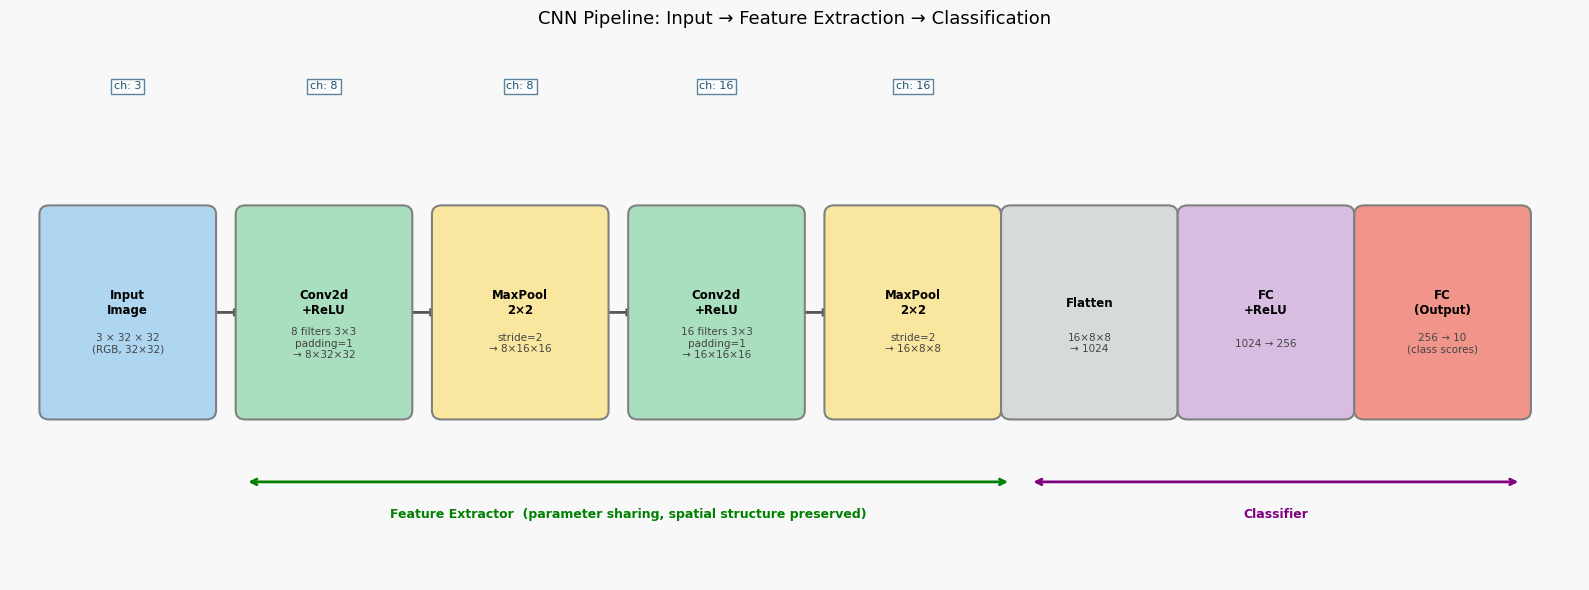

In [8]:
# ── Full CNN pipeline diagram ──
# Show tensor shapes at each stage with visual blocks

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.set_xlim(0, 16)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#F8F8F8')
fig.patch.set_facecolor('#F8F8F8')
ax.set_title('CNN Pipeline: Input → Feature Extraction → Classification',
             fontsize=13, pad=15)

def draw_block(ax, x, y, w, h, color, label, sublabel='', fontsize=9):
    rect = mpatches.FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle='round,pad=0.1', facecolor=color, edgecolor='gray',
        linewidth=1.5, zorder=3)
    ax.add_patch(rect)
    ax.text(x, y + (0.1 if sublabel else 0), label,
            ha='center', va='center', fontsize=fontsize,
            fontweight='bold', zorder=4)
    if sublabel:
        ax.text(x, y-0.35, sublabel,
                ha='center', va='center', fontsize=7.5,
                color='#444', zorder=4)

def draw_arrow(ax, x1, x2, y=3.0):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='->', color='#555',
                                lw=2), zorder=2)

# Stage positions
stages = [
    (1.2,  '#AED6F1', 'Input\nImage',     '3 × 32 × 32\n(RGB, 32×32)'),
    (3.2,  '#A9DFBF', 'Conv2d\n+ReLU',    '8 filters 3×3\npadding=1\n→ 8×32×32'),
    (5.2,  '#F9E79F', 'MaxPool\n2×2',     'stride=2\n→ 8×16×16'),
    (7.2,  '#A9DFBF', 'Conv2d\n+ReLU',    '16 filters 3×3\npadding=1\n→ 16×16×16'),
    (9.2,  '#F9E79F', 'MaxPool\n2×2',     'stride=2\n→ 16×8×8'),
    (11.0, '#D5DBDB', 'Flatten',          '16×8×8\n→ 1024'),
    (12.8, '#D7BDE2', 'FC\n+ReLU',        '1024 → 256'),
    (14.6, '#F1948A', 'FC\n(Output)',     '256 → 10\n(class scores)'),
]

for (x, color, label, sub) in stages:
    draw_block(ax, x, 3.0, 1.6, 2.2, color, label, sub, fontsize=8.5)

# Arrows
xs = [s[0] for s in stages]
for i in range(len(xs)-1):
    draw_arrow(ax, xs[i]+0.8, xs[i+1]-0.8)

# Brace labels below
ax.annotate('', xy=(10.2, 1.1), xytext=(2.4, 1.1),
            arrowprops=dict(arrowstyle='<->', color='green', lw=2))
ax.text(6.3, 0.7, 'Feature Extractor  (parameter sharing, spatial structure preserved)',
        ha='center', fontsize=9, color='green', fontweight='bold')

ax.annotate('', xy=(15.4, 1.1), xytext=(10.4, 1.1),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(12.9, 0.7, 'Classifier',
        ha='center', fontsize=9, color='purple', fontweight='bold')

# Channel annotation
ax.text(1.2, 5.5, 'ch: 3', ha='center', fontsize=8, color='#1a5276',
        bbox=dict(facecolor='white', edgecolor='#1a5276', alpha=0.7, pad=2))
ax.text(3.2, 5.5, 'ch: 8', ha='center', fontsize=8, color='#1a5276',
        bbox=dict(facecolor='white', edgecolor='#1a5276', alpha=0.7, pad=2))
ax.text(5.2, 5.5, 'ch: 8', ha='center', fontsize=8, color='#1a5276',
        bbox=dict(facecolor='white', edgecolor='#1a5276', alpha=0.7, pad=2))
ax.text(7.2, 5.5, 'ch: 16', ha='center', fontsize=8, color='#1a5276',
        bbox=dict(facecolor='white', edgecolor='#1a5276', alpha=0.7, pad=2))
ax.text(9.2, 5.5, 'ch: 16', ha='center', fontsize=8, color='#1a5276',
        bbox=dict(facecolor='white', edgecolor='#1a5276', alpha=0.7, pad=2))

plt.tight_layout()
plt.show()

In [9]:
# ── Summary table: all concepts in one place ──

print("="*65)
print(f"{'CNN 핵심 용어 요약':^65}")
print("="*65)

terms = [
    ("필터(Filter / Kernel)",
     "이미지에서 특정 패턴을 찾는 작은 숫자 배열 (e.g. 3×3)"),
    ("Convolution",
     "필터를 이미지 위에 슬라이딩하며 점곱을 계산하는 연산"),
    ("채널(Channel)",
     "같은 공간을 보는 서로 다른 관점의 수\n"
     "  입력: RGB=3채널, 출력: 필터 개수=출력 채널 수"),
    ("Feature Map",
     "필터 하나를 이미지 전체에 적용한 결과\n"
     "  각 위치값 = 해당 위치에서 패턴의 강도"),
    ("패딩(Padding)",
     "이미지 경계에 0을 덧댐 → 출력 크기 유지\n"
     "  padding=1, kernel=3 → 입출력 크기 동일"),
    ("스트라이드(Stride)",
     "필터 이동 보폭. stride=2 → 출력 크기 약 절반"),
    ("풀링(Pooling)",
     "feature map 크기를 줄이는 연산 (파라미터 없음)\n"
     "  MaxPool: 2×2 영역에서 최댓값 선택"),
    ("파라미터 공유",
     "하나의 필터가 이미지 전체를 훑음\n"
     "  → FC 대비 파라미터 수 수백 배 절감"),
]

for term, desc in terms:
    print(f"\n▸ {term}")
    for line in desc.split('\n'):
        print(f"  {line}")

print("\n" + "="*65)

                          CNN 핵심 용어 요약                           

▸ 필터(Filter / Kernel)
  이미지에서 특정 패턴을 찾는 작은 숫자 배열 (e.g. 3×3)

▸ Convolution
  필터를 이미지 위에 슬라이딩하며 점곱을 계산하는 연산

▸ 채널(Channel)
  같은 공간을 보는 서로 다른 관점의 수
    입력: RGB=3채널, 출력: 필터 개수=출력 채널 수

▸ Feature Map
  필터 하나를 이미지 전체에 적용한 결과
    각 위치값 = 해당 위치에서 패턴의 강도

▸ 패딩(Padding)
  이미지 경계에 0을 덧댐 → 출력 크기 유지
    padding=1, kernel=3 → 입출력 크기 동일

▸ 스트라이드(Stride)
  필터 이동 보폭. stride=2 → 출력 크기 약 절반

▸ 풀링(Pooling)
  feature map 크기를 줄이는 연산 (파라미터 없음)
    MaxPool: 2×2 영역에서 최댓값 선택

▸ 파라미터 공유
  하나의 필터가 이미지 전체를 훑음
    → FC 대비 파라미터 수 수백 배 절감



---

이 섹션의 모든 시각화를 직접 실행해봤다면 Part 1으로 넘어갈 준비가 된 것입니다.

---

# Part 1 — 강의 영상 복습

## 1. Convolution이란?

### 직관: 필터로 이미지를 훑는다

Convolution의 핵심 아이디어는 **작은 필터(filter / kernel)로 이미지를 슬라이딩하며 특징을 추출**하는 것입니다.

실생활 예시로 생각해보세요:
- 사진에서 **가장자리(edge)** 를 찾고 싶다면? → 가장자리를 검출하는 필터를 만들어 이미지 전체를 훑으면 됩니다.
- **대각선**을 찾고 싶다면? → 대각선 필터를 사용하면 됩니다.

CNN에서는 이 필터의 값들을 **학습으로 찾습니다**. "어떤 특징을 찾아야 분류를 잘 할 수 있는가"를 데이터로부터 자동으로 배우는 것입니다.

### Convolution 연산 시각화

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

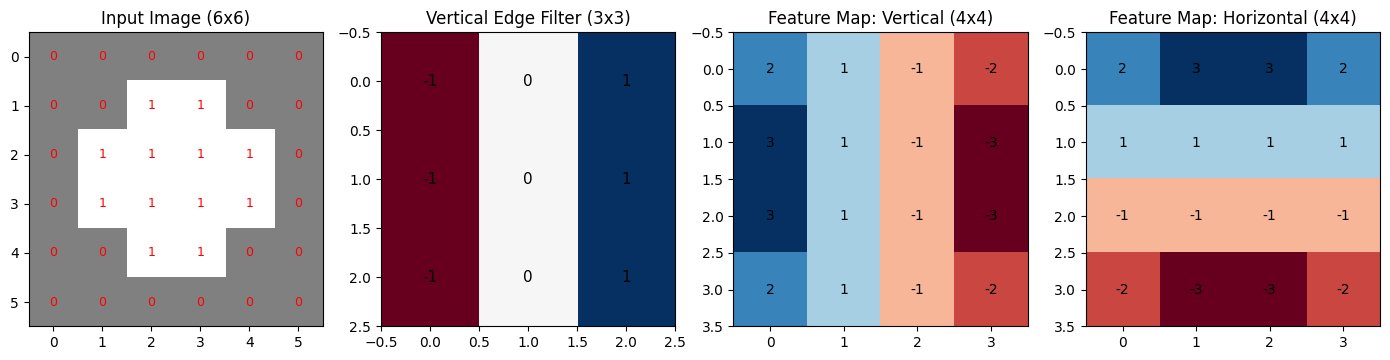

Input size: 6x6
Filter size: 3x3, stride=1, padding=0
Output size: 4x4


In [11]:
# Simple 6x6 image (grayscale, hand-drawn)
image = np.array([
    [0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 1, 1, 1, 1, 0],
    [0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0],
], dtype=float)

# Vertical edge detection filter
filter_vertical = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

# Horizontal edge detection filter
filter_horizontal = np.array([
    [-1, -1, -1],
    [ 0,  0,  0],
    [ 1,  1,  1],
])

# Manual convolution (stride=1, no padding)
def manual_conv2d(image, kernel):
    H, W = image.shape
    kH, kW = kernel.shape
    out_H = H - kH + 1  # output height
    out_W = W - kW + 1  # output width
    output = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            # Element-wise multiply and sum
            output[i, j] = np.sum(image[i:i+kH, j:j+kW] * kernel)
    return output

feat_v = manual_conv2d(image, filter_vertical)
feat_h = manual_conv2d(image, filter_horizontal)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

axes[0].imshow(image, cmap='gray', vmin=-1, vmax=1)
axes[0].set_title('Input Image (6x6)')
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, str(int(image[i,j])), ha='center', va='center', color='red', fontsize=9)

axes[1].imshow(filter_vertical, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('Vertical Edge Filter (3x3)')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, str(filter_vertical[i,j]), ha='center', va='center', fontsize=11)

axes[2].imshow(feat_v, cmap='RdBu')
axes[2].set_title('Feature Map: Vertical (4x4)')
for i in range(4):
    for j in range(4):
        axes[2].text(j, i, str(int(feat_v[i,j])), ha='center', va='center', fontsize=10)

axes[3].imshow(feat_h, cmap='RdBu')
axes[3].set_title('Feature Map: Horizontal (4x4)')
for i in range(4):
    for j in range(4):
        axes[3].text(j, i, str(int(feat_h[i,j])), ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Input size: 6x6")
print("Filter size: 3x3, stride=1, padding=0")
print(f"Output size: {feat_v.shape[0]}x{feat_v.shape[1]}")

수직 엣지 필터는 왼쪽-오른쪽 픽셀 차이를 감지하고, 수평 엣지 필터는 위-아래 픽셀 차이를 감지합니다. Feature map에서 값이 크면 해당 위치에 그 특징이 존재한다는 의미입니다.

**CNN의 핵심**: 이런 필터의 값들을 사람이 직접 설계하는 것이 아니라, **역전파로 학습**합니다.

---

## 2. Feature Map 크기와 파라미터 수 계산

### Feature Map 크기 공식

입력 크기 $H \times W$, 필터 크기 $F \times F$, 패딩 $P$, 스트라이드 $S$일 때:

$$\text{Output size} = \left\lfloor \frac{H + 2P - F}{S} \right\rfloor + 1$$

예시:

| 입력 | 필터 | 패딩 | 스트라이드 | 출력 |
|------|------|------|-----------|------|
| 6×6 | 3×3 | 0 | 1 | 4×4 |
| 32×32 | 3×3 | 1 | 1 | 32×32 |
| 32×32 | 3×3 | 0 | 1 | 30×30 |
| 32×32 | 5×5 | 2 | 1 | 32×32 |

**패딩=1, 필터=3×3, 스트라이드=1** 이면 입력 크기가 그대로 유지됩니다. 이 조합이 CNN에서 가장 많이 쓰입니다.

### 파라미터 수 계산

`nn.Conv2d(in_channels, out_channels, kernel_size)` 의 파라미터 수:

$$\text{파라미터 수} = (F \times F \times C_{in} + 1) \times C_{out}$$

- $F \times F$: 필터 크기
- $C_{in}$: 입력 채널 수
- $+1$: bias 1개
- $C_{out}$: 필터(출력 채널) 개수

예시: `Conv2d(3, 32, 3)` → $(3 \times 3 \times 3 + 1) \times 32 = 896$ 개

In [12]:
# Confirming with PyTorch
conv = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)

# Count parameters
weight_params = conv.weight.numel()  # F*F*C_in * C_out
bias_params   = conv.bias.numel()    # C_out
total_params  = weight_params + bias_params

print(f"Weight shape : {conv.weight.shape}  →  {weight_params} params")
print(f"Bias shape   : {conv.bias.shape}  →  {bias_params} params")
print(f"Total params : {total_params}")
print("\n32×32×3 = 3072픽셀짜리 이미지를 다루는데 파라미터가 896개뿐입니다.")
print("이것이 파라미터 공유(parameter sharing)의 힘입니다.")

Weight shape : torch.Size([32, 3, 3, 3])  →  864 params
Bias shape   : torch.Size([32])  →  32 params
Total params : 896

32×32×3 = 3072픽셀짜리 이미지를 다루는데 파라미터가 896개뿐입니다.
이것이 파라미터 공유(parameter sharing)의 힘입니다.


CNN이 FC보다 훨씬 적은 파라미터를 사용할 수 있는 이유:

- **파라미터 공유(Parameter Sharing)**: 하나의 필터가 이미지 전체를 훑습니다. "같은 특징 검출기를 이미지의 모든 위치에 재사용한다"
- **지역 연결(Local Connectivity)**: 필터는 입력 전체가 아니라 작은 영역(receptive field)만 보고 계산합니다. 3×3 필터라면 한 번에 3×3 패치만 참조합니다.

---

## 3. Pooling

Convolution으로 feature map을 만든 후, **Pooling**으로 크기를 줄입니다.

가장 많이 쓰이는 방식은 **Max Pooling**: 2×2 영역에서 최댓값만 남깁니다.

Pooling의 역할:
1. **공간 크기 축소** → 계산량, 파라미터 감소
2. **위치 불변성(Translation Invariance)** → 특징이 이미지에서 조금 이동해도 동일하게 감지
3. **Overfitting 억제** (일종의 정보 압축)

In [13]:
# MaxPool2d example
feature_map = torch.tensor([
    [1., 3., 2., 4.],
    [5., 6., 1., 2.],
    [1., 2., 3., 4.],
    [7., 5., 4., 6.],
]).unsqueeze(0).unsqueeze(0)  # shape: (1, 1, 4, 4)  batch, channel, H, W

pool = nn.MaxPool2d(kernel_size=2, stride=2)
pooled = pool(feature_map)

print("Before pooling:", feature_map.shape, "→")
print(feature_map.squeeze())
print("\nAfter MaxPool2d(2,2):", pooled.shape, "→")
print(pooled.squeeze())
print("\n각 2x2 블록에서 최댓값을 선택합니다.")

Before pooling: torch.Size([1, 1, 4, 4]) →
tensor([[1., 3., 2., 4.],
        [5., 6., 1., 2.],
        [1., 2., 3., 4.],
        [7., 5., 4., 6.]])

After MaxPool2d(2,2): torch.Size([1, 1, 2, 2]) →
tensor([[6., 4.],
        [7., 6.]])

각 2x2 블록에서 최댓값을 선택합니다.


---

## 4. 기본 CNN 구조

CNN은 보통 다음 패턴을 반복합니다:

$$\text{Conv} \rightarrow \text{ReLU} \rightarrow \text{MaxPool} \rightarrow \cdots \rightarrow \text{Flatten} \rightarrow \text{FC} \rightarrow \text{출력}$$

앞부분(Conv 블록들)은 **특징 추출기(Feature Extractor)**, 뒷부분(FC 층들)은 **분류기(Classifier)** 라고 부릅니다.

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Feature extractor
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # 32x32x3  -> 32x32x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 16x16x32 -> 16x16x64
        self.pool  = nn.MaxPool2d(2, 2)                            # halves H and W

        # Classifier
        # After conv1+pool: 16x16x32
        # After conv2+pool: 8x8x64
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Block 1
        x = F.relu(self.conv1(x))
        x = self.pool(x)            # 32x32 -> 16x16

        # Block 2
        x = F.relu(self.conv2(x))
        x = self.pool(x)            # 16x16 -> 8x8

        # Flatten: (batch, 64, 8, 8) -> (batch, 64*8*8)
        x = x.view(x.size(0), -1)

        # FC layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=10)

# Check shapes with a dummy input
dummy = torch.randn(4, 3, 32, 32)  # batch=4, RGB, 32x32
out = model(dummy)
print(f"Input shape : {dummy.shape}")
print(f"Output shape: {out.shape}  (batch=4, classes=10)")

# Count total parameters
total = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total:,}")

Input shape : torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])  (batch=4, classes=10)

Total parameters: 1,070,794


In [15]:
# Shape tracking — where does the tensor go?
print("=== Shape 추적 ===")
x = torch.randn(1, 3, 32, 32)
print(f"Input          : {x.shape}")

x = F.relu(model.conv1(x))
print(f"After conv1    : {x.shape}   (32 filters, padding=1 → size maintained)")

x = model.pool(x)
print(f"After pool     : {x.shape}   (32x32 → 16x16)")

x = F.relu(model.conv2(x))
print(f"After conv2    : {x.shape}  (64 filters, padding=1 → size maintained)")

x = model.pool(x)
print(f"After pool     : {x.shape}   (16x16 → 8x8)")

x = x.view(x.size(0), -1)
print(f"After flatten  : {x.shape}  (64*8*8=4096)")

x = F.relu(model.fc1(x))
print(f"After fc1      : {x.shape}")

x = model.fc2(x)
print(f"After fc2      : {x.shape}   (10 classes)")

=== Shape 추적 ===
Input          : torch.Size([1, 3, 32, 32])
After conv1    : torch.Size([1, 32, 32, 32])   (32 filters, padding=1 → size maintained)
After pool     : torch.Size([1, 32, 16, 16])   (32x32 → 16x16)
After conv2    : torch.Size([1, 64, 16, 16])  (64 filters, padding=1 → size maintained)
After pool     : torch.Size([1, 64, 8, 8])   (16x16 → 8x8)
After flatten  : torch.Size([1, 4096])  (64*8*8=4096)
After fc1      : torch.Size([1, 256])
After fc2      : torch.Size([1, 10])   (10 classes)


---

## 5. CIFAR-10 학습 전체 파이프라인

CIFAR-10은 10개 클래스(비행기, 자동차, 새, 고양이, 사슴, 개, 개구리, 말, 배, 트럭)로 이루어진 32×32 컬러 이미지 데이터셋입니다. 학습 50,000장, 테스트 10,000장.

**정규화(Normalization)**: 각 채널의 평균과 표준편차로 정규화합니다. CIFAR-10에 대해 미리 계산된 값을 사용합니다.

In [16]:
# CIFAR-10 dataset loading
# mean/std precomputed from the CIFAR-10 training set
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=transform)

# shuffle=True: 에포크마다 데이터 순서를 섞음 → 학습 안정성 향상 (학습용에만 적용)
# shuffle=False: 평가 시에는 순서 유지 (결과 재현성)
# num_workers=2: 데이터 로딩을 별도 프로세스 2개가 병렬로 처리
#                GPU가 현재 배치를 학습하는 동안 다음 배치를 미리 준비 → 대기시간 감소

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)} images, {len(train_loader)} batches")
print(f"Test : {len(test_dataset)} images, {len(test_loader)} batches")

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

100%|██████████| 170M/170M [00:19<00:00, 8.90MB/s] 


Train: 50000 images, 391 batches
Test : 10000 images, 79 batches


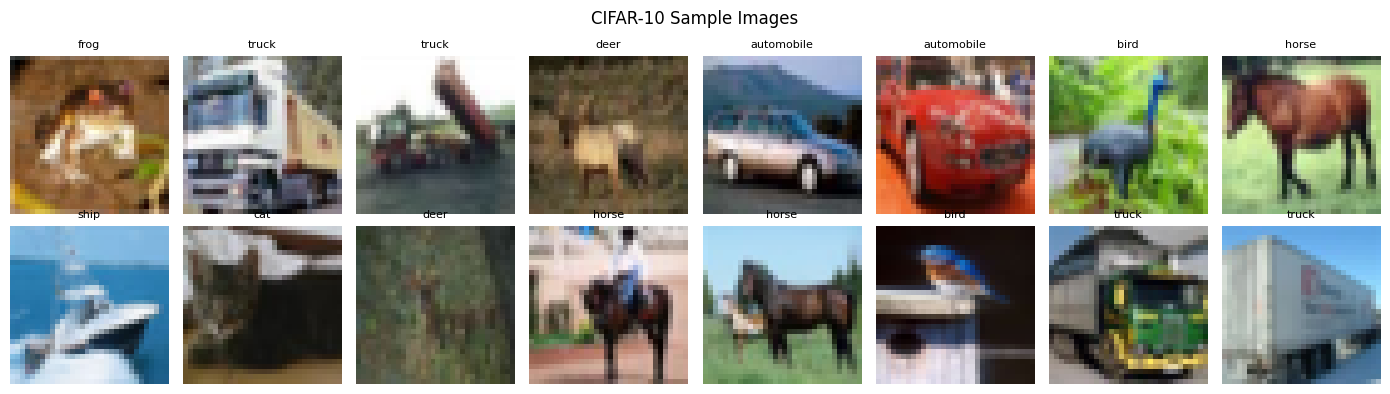

In [17]:
# 학습 이미지 샘플 시각화 (화면 표시를 위해 정규화 역변환 필요)
# CIFAR-10 원본: uint8, 0~255
#   ↓ ToTensor()
# float32, 0~1  (÷255 자동 수행)
#   ↓ Normalize(mean, std)
# float32, 범위 제한 없음 (음수 포함)
#   ↓ * std + mean  (역정규화)
# float32, 0~1  (clamp으로 오차 보정)
#   ↓ imshow()
# imshow()의 경우, float 배열(0~1) 또는 int 배열(0~255) 모두 자동으로 정상 표시

# train_dataset은 정규화된 상태이므로, 원래 픽셀값으로 되돌린 후 표시

# CIFAR10_MEAN, CIFAR10_STD는 각각 채널별 평균/표준편차 3개짜리 튜플 (R, G, B)
# view(3, 1, 1): shape을 (3,)에서 (3, 1, 1)로 변환
# img의 shape은 (3, 32, 32)이므로, mean/std도 (3, 1, 1)이어야
# PyTorch 브로드캐스팅이 채널 0↔채널 0, 채널 1↔채널 1, 채널 2↔채널 2로 올바르게 대응됨
# (3,) 그대로 두면 마지막 차원(W=32)에 맞추려 해서 shape 불일치 오류 발생

mean = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std  = torch.tensor(CIFAR10_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]  # img: 정규화된 텐서 (3, 32, 32), label: 클래스 인덱스(0~9)

    # 역정규화: * std + mean → ToTensor()로 변환된 [0, 1] 범위로 복원
    # (ToTensor가 0~255 픽셀을 0~1로 먼저 변환했으므로, 역정규화 결과도 [0, 1])
    # clamp(0, 1): 부동소수점 오차로 범위를 살짝 벗어날 수 있으므로 강제로 [0, 1]에 고정
    img_display = (img * std + mean).clamp(0, 1)

    # permute(1, 2, 0): PyTorch (C, H, W) → matplotlib (H, W, C) 순서로 변환
    # .numpy(): 텐서를 numpy 배열로 변환 (matplotlib은 numpy 배열을 입력으로 받음)
    ax.imshow(img_display.permute(1, 2, 0).numpy())

    ax.set_title(CLASS_NAMES[label], fontsize=8)  # 클래스 이름을 제목으로 표시 (영문: 한글 폰트 미설치)
    ax.axis('off')  # 축 눈금 제거

plt.suptitle('CIFAR-10 Sample Images', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# 전체 학습 루프 (학습 + 평가를 에포크마다 반복)

# GPU가 있으면 GPU, 없으면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 모델, 손실함수, 옵티마이저, 스케줄러 초기화
model     = SimpleCNN(num_classes=10).to(device)  # 모델을 device로 이동
criterion = nn.CrossEntropyLoss()                 # 다중 클래스 분류 손실함수 (softmax 내장)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
# StepLR: 10 에포크마다 학습률을 0.5배로 감소 (1e-3 → 5e-4 → 2.5e-4)

NUM_EPOCHS = 20

# 에포크별 loss와 정확도를 기록할 리스트
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(NUM_EPOCHS):

    # ── 학습 단계 ──────────────────────────────────────
    model.train()  # Dropout/BatchNorm을 학습 모드로 전환
    running_loss, correct, total = 0.0, 0, 0  # 에포크 누적 통계 초기화

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)  # 데이터를 device로 이동

        optimizer.zero_grad()          # 이전 배치의 gradient 초기화 (누적 방지)
        outputs = model(images)        # 순전파: (batch, 10) 크기의 logit 출력
        loss    = criterion(outputs, labels)  # 손실 계산
        loss.backward()                # 역전파: 각 파라미터의 gradient 계산
        optimizer.step()               # gradient로 파라미터 업데이트

        # 배치 손실을 이미지 수로 가중합산 (나중에 전체 평균을 내기 위해)
        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)             # 각 샘플에서 가장 큰 logit의 인덱스 = 예측 클래스
        total        += labels.size(0)             # 전체 샘플 수 누적
        correct      += predicted.eq(labels).sum().item()  # 정답 수 누적

    train_loss = running_loss / total  # 에포크 평균 손실
    train_acc  = correct / total       # 에포크 정확도

    # ── 평가 단계 ──────────────────────────────────────
    model.eval()  # Dropout 비활성화, BatchNorm을 추론 모드로 전환
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():  # gradient 계산 비활성화 (메모리 절약, 속도 향상)
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

    test_loss = running_loss / total
    test_acc  = correct / total

    # 에포크 결과 기록
    train_losses.append(train_loss); test_losses.append(test_loss)
    train_accs.append(train_acc);   test_accs.append(test_acc)
    scheduler.step()  # 학습률 스케줄러 업데이트 (step_size 에포크마다 lr 감소)

    # 5 에포크마다 중간 결과 출력
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
              f"Train Loss: {train_loss:.3f}, Acc: {train_acc*100:.1f}%  |  "
              f"Test Loss: {test_loss:.3f}, Acc: {test_acc*100:.1f}%")

Using device: cuda
Epoch [ 5/20]  Train Loss: 0.788, Acc: 72.3%  |  Test Loss: 0.816, Acc: 71.7%
Epoch [10/20]  Train Loss: 0.514, Acc: 81.8%  |  Test Loss: 0.779, Acc: 73.9%
Epoch [15/20]  Train Loss: 0.306, Acc: 89.0%  |  Test Loss: 0.852, Acc: 75.0%
Epoch [20/20]  Train Loss: 0.226, Acc: 91.7%  |  Test Loss: 0.993, Acc: 74.7%


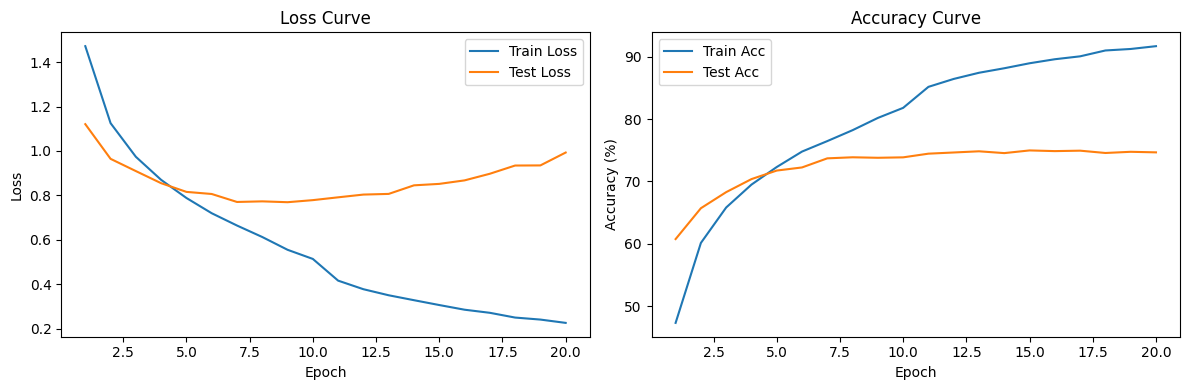

Final Test Accuracy: 74.7%


In [19]:
# Plot training curves
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, test_losses,  label='Test Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve'); ax1.legend()

ax2.plot(epochs, [a*100 for a in train_accs], label='Train Acc')
ax2.plot(epochs, [a*100 for a in test_accs],  label='Test Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curve'); ax2.legend()

plt.tight_layout()
plt.show()
print(f"Final Test Accuracy: {test_accs[-1]*100:.1f}%")

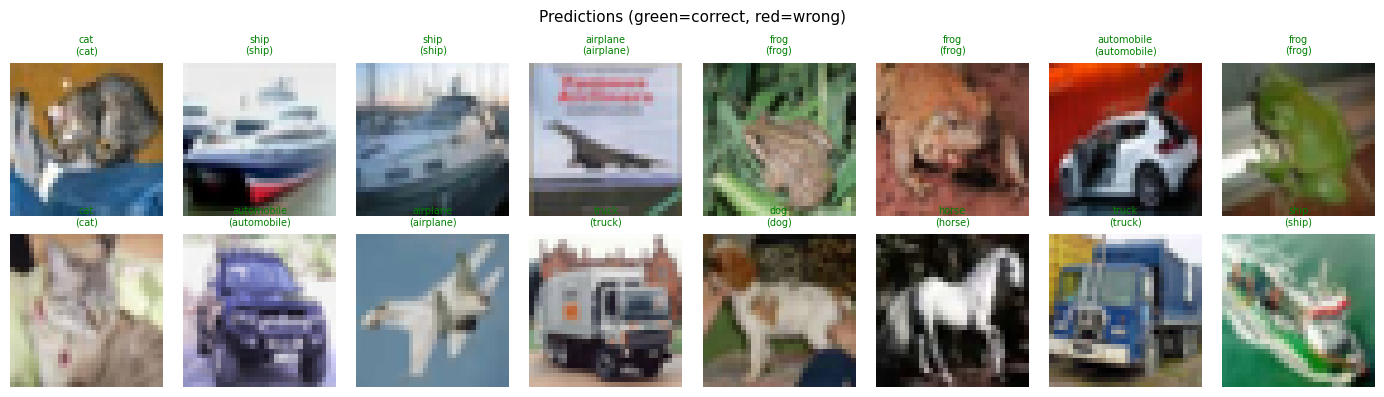

In [20]:
# Visualize predictions
model.eval()
images, labels = next(iter(test_loader))
images_dev = images[:16].to(device)
with torch.no_grad():
    outputs = model(images_dev)
_, preds = outputs.max(1)

# Denormalize for display
mean = torch.tensor(CIFAR10_MEAN).view(3,1,1)
std  = torch.tensor(CIFAR10_STD).view(3,1,1)
imgs_display = images[:16] * std + mean
imgs_display = imgs_display.clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_display[i].permute(1, 2, 0).numpy())
    pred  = CLASS_NAMES[preds[i].item()]
    truth = CLASS_NAMES[labels[i].item()]
    color = 'green' if pred == truth else 'red'
    ax.set_title(f"{pred}\n({truth})", fontsize=7, color=color)
    ax.axis('off')
plt.suptitle('Predictions (green=correct, red=wrong)', fontsize=11)
plt.tight_layout()
plt.show()

---

## 6. CNN이 학습한 필터 시각화

CNN의 첫 번째 Convolution 층이 학습한 필터들을 직접 시각화해봅니다. 학습 초반에는 무작위처럼 보이지만, 충분히 학습되면 엣지, 색상, 텍스처 등 의미있는 패턴을 감지하는 필터가 형성됩니다.

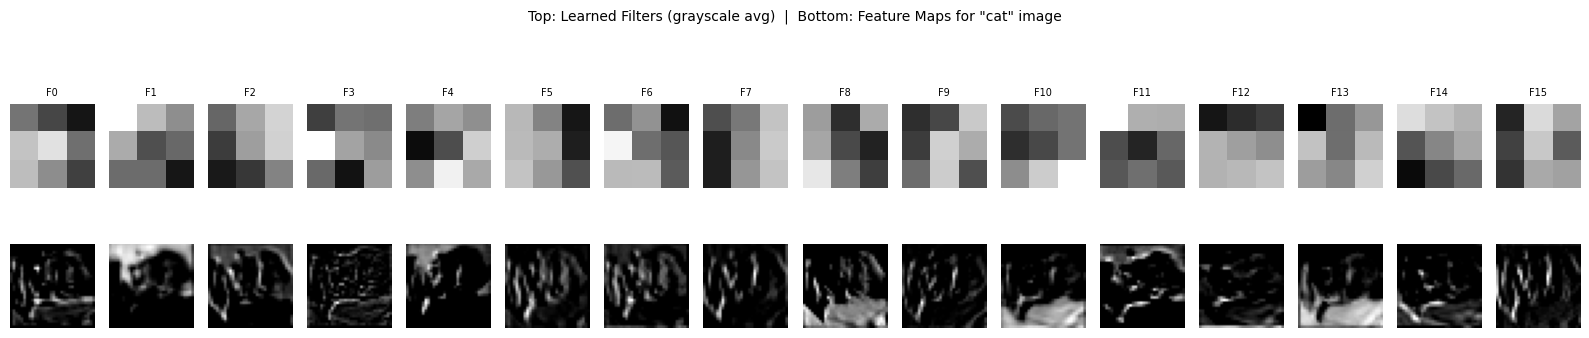

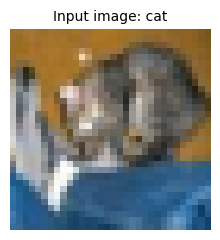

In [21]:
# conv1이 학습한 필터 시각화
# 왼쪽: 필터 자체를 흑백(채널 평균)으로 표시 — 엣지 방향 등 패턴 확인
# 오른쪽: 실제 이미지를 넣었을 때 각 필터의 반응(feature map) — 필터가 무엇을 감지하는지 확인

model.eval()

# ── 준비: 필터 가중치와 테스트 이미지 한 장 ──────────────────────
filters = model.conv1.weight.data.cpu()  # shape: (32, 3, 3, 3) = (필터수, 입력채널, H, W)

# 테스트 이미지 한 장을 가져와서 conv1 통과 후 feature map 계산
sample_img, sample_label = test_dataset[0]
sample_input = sample_img.unsqueeze(0).to(device)  # (3, 32, 32) → (1, 3, 32, 32): 배치 차원 추가
with torch.no_grad():
    feature_maps = F.relu(model.conv1(sample_input))  # shape: (1, 32, 32, 32)
feature_maps = feature_maps.squeeze(0).cpu()           # 배치 차원 제거 → (32, 32, 32)

# ── 시각화: 위=필터(흑백), 아래=feature map ───────────────────────
NUM_SHOW = 16  # 32개 중 16개만 표시 (공간 절약)
fig, axes = plt.subplots(2, NUM_SHOW, figsize=(16, 4))
fig.suptitle(
    f'Top: Learned Filters (grayscale avg)  |  '
    f'Bottom: Feature Maps for "{CLASS_NAMES[sample_label]}" image',
    fontsize=10
)

for i in range(NUM_SHOW):
    # 위쪽 행: 필터를 채널 평균으로 흑백 표시
    # 3채널 평균 → 2D (3,3) 배열: 엣지 방향, 명암 차이 등의 패턴이 드러남.
    # gray 컬러맵: 값이 클수록 밝게 표시 → 공간적 패턴(어느 위치가 강한지) 파악에 유리
    # vmin/vmax를 표준편차 2배 범위로 설정: 이상치에 의해 패턴이 뭉개지는 것을 방지
    filt_gray = filters[i].mean(dim=0).numpy()  # (3,3,3) → 채널 평균 → (3,3)
    ax_top = axes[0, i]
    ax_top.imshow(filt_gray, cmap='gray', vmin=-filt_gray.std()*2, vmax=filt_gray.std()*2)
    ax_top.set_title(f'F{i}', fontsize=7)
    ax_top.axis('off')

    # 아래쪽 행: 해당 필터의 feature map (실제 이미지에 대한 반응)
    # 밝을수록 해당 위치에서 이 필터의 패턴이 강하게 감지됨
    fmap = feature_maps[i].numpy()  # (32, 32)
    ax_bot = axes[1, i]
    ax_bot.imshow(fmap, cmap='gray')
    ax_bot.axis('off')

plt.tight_layout()
plt.show()

# 원본 이미지도 나란히 표시
mean_t = torch.tensor(CIFAR10_MEAN).view(3, 1, 1)
std_t  = torch.tensor(CIFAR10_STD).view(3, 1, 1)
img_display = (sample_img * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
fig2, ax2 = plt.subplots(1, 1, figsize=(2.5, 2.5))
ax2.imshow(img_display)
ax2.set_title(f'Input image: {CLASS_NAMES[sample_label]}', fontsize=10)
ax2.axis('off')
plt.tight_layout()
plt.show()

---

## 7. 다음 주 예고

9주차에서는 직접 CNN을 만들고 CIFAR-10을 분류해보았습니다.

그런데 지금 만든 CNN은 테스트 정확도가 약 70% 수준입니다. 10주차에서는:

- **ResNet**: "잔차 연결"로 훨씬 깊은 네트워크를 안정적으로 학습
- **Transfer Learning**: 대규모 데이터로 미리 학습된 모델을 재활용
- **Data Augmentation**: 데이터를 인위적으로 늘려 일반화 성능 향상

이 기법들을 조합하면 같은 CIFAR-10에서 90% 이상의 정확도를 달성할 수 있습니다.

---

# Part 2 — 실습 (100분)

> **목표**: CNN 구조를 코드 레벨에서 이해하고, 직접 조립해보기

## [A] 한 줄 채우기 (10문제)

### A-1. Feature map 크기 계산

In [22]:
def output_size(H, F, P, S):
    """
    주어진 파라미터로 Convolution 출력 크기를 계산합니다.
    H: input height (= width, assume square)
    F: filter size
    P: padding
    S: stride
    """
    # 공식: floor((H + 2P - F) / S) + 1
    return ______

# Tests
print(output_size(32, 3, 1, 1))  # expected: 32
print(output_size(32, 3, 0, 1))  # expected: 30
print(output_size(32, 5, 2, 1))  # expected: 32
print(output_size(16, 2, 0, 2))  # expected: 8  (MaxPool2d(2,2)와 같음)

NameError: name '______' is not defined

### A-2. Conv2d 파라미터 수 계산

In [ ]:
def count_conv_params(C_in, C_out, F, bias=True):
    """
    Conv2d(C_in, C_out, F) 의 파라미터 수를 계산합니다.
    bias=True이면 bias 파라미터도 포함.
    """
    weight_params = ______
    bias_params   = C_out if bias else 0
    return weight_params + bias_params

# Test: Conv2d(3, 32, 3) -> expected: 896
print(count_conv_params(3, 32, 3))   # 896
print(count_conv_params(32, 64, 3))  # expected: 18496

# Verify with PyTorch
conv_test = nn.Conv2d(3, 32, 3)
actual = sum(p.numel() for p in conv_test.parameters())
print(f"PyTorch actual: {actual}")

### A-3. Conv2d 레이어 선언

In [ ]:
# 입력 채널 16, 출력 채널 32, 필터 크기 3, 패딩 1인 Conv2d 레이어를 선언하세요.
conv_layer = ______

# 확인
x = torch.randn(8, 16, 14, 14)  # batch=8, C=16, H=W=14
out = conv_layer(x)
print(f"Input : {x.shape}")
print(f"Output: {out.shape}")   # expected: torch.Size([8, 32, 14, 14])

### A-4. MaxPool2d 적용

In [ ]:
# kernel_size=2, stride=2 인 MaxPool2d를 선언하고, 위의 out에 적용하세요.
pool_layer = ______
pooled_out = ______

print(f"Before pool: {out.shape}")
print(f"After pool : {pooled_out.shape}")  # expected: [8, 32, 7, 7]

### A-5. Flatten

In [ ]:
# pooled_out (shape: [8, 32, 7, 7])을 FC 층에 넣으려면 2D로 펼쳐야 합니다.
# batch 차원은 유지하고, 나머지를 1D로 펼치세요. (view 또는 flatten 사용)
flattened = ______

print(f"Before flatten: {pooled_out.shape}")
print(f"After flatten : {flattened.shape}")  # expected: [8, 1568]  (32*7*7=1568)

### A-6. forward() 안의 Conv 블록 완성

In [ ]:
class MiniCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # grayscale input
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc    = nn.Linear(32 * 7 * 7, 10)  # MNIST: 28x28 -> pool -> 14x14 -> pool -> 7x7

    def forward(self, x):
        # Block 1: conv1 -> ReLU -> pool
        x = ______

        # Block 2: conv2 -> ReLU -> pool
        x = ______

        # Flatten
        x = x.view(x.size(0), -1)

        # FC output
        x = self.fc(x)
        return x

mini_model = MiniCNN()
dummy_mnist = torch.randn(4, 1, 28, 28)  # MNIST-like input
out = mini_model(dummy_mnist)
print(f"Output shape: {out.shape}")  # expected: [4, 10]

### A-7. model.train() / model.eval() 적용

In [ ]:
model_a7 = SimpleCNN()

# 학습 루프 시작 전, 모델을 학습 모드로 전환하세요.
______
print(f"Training mode: {model_a7.training}")  # expected: True

# 평가 루프 시작 전, 모델을 평가 모드로 전환하세요.
______
print(f"Training mode: {model_a7.training}")  # expected: False

### A-8. 정확도 계산

In [ ]:
# 아래 outputs (logits)으로부터 예측 클래스를 구하고, labels와 비교하여 정확도를 계산하세요.
# Hint: outputs.max(1)는 (최댓값, 인덱스)를 반환합니다.

outputs_sample = torch.tensor([
    [2.1, 0.3, -1.0, 0.5],   # predicted: 0
    [0.1, 0.2,  3.5, 0.1],   # predicted: 2
    [0.0, 2.8,  0.1, 0.2],   # predicted: 1
    [0.5, 0.1, -0.2, 1.9],   # predicted: 3
])
labels_sample = torch.tensor([0, 2, 0, 3])  # ground truth

_, predicted = ______
accuracy = ______

print(f"Predicted : {predicted.tolist()}")
print(f"Labels    : {labels_sample.tolist()}")
print(f"Accuracy  : {accuracy:.2f}")  # expected: 0.75 (3 out of 4 correct)

### A-9. CrossEntropyLoss

In [ ]:
# CrossEntropyLoss를 선언하고, outputs_sample과 labels_sample로 loss를 계산하세요.
# 주의: CrossEntropyLoss는 logits(softmax 이전 값)을 입력으로 받습니다.

criterion_a9 = ______
loss_a9      = ______
print(f"Loss: {loss_a9.item():.4f}")

### A-10. 전체 모델 파라미터 수 세기

In [ ]:
# SimpleCNN의 전체 파라미터 수를 계산하세요.
# Hint: model.parameters()를 순회하고 각 p.numel()을 합산합니다.

model_a10 = SimpleCNN()
total_params = ______
print(f"Total parameters: {total_params:,}")

---

## [B] 여러 줄 채우기 — CNN 구조 직접 설계하기 ⭐ (숙제 가능)

**목표**: Conv 블록을 3개 사용하는 `DeepCNN`을 직접 구현하고, `SimpleCNN`과 성능을 비교해보세요.

**구조 힌트**:
```
Input: (B, 3, 32, 32)
Block 1: Conv2d(3→32, k=3, p=1) → BN → ReLU → MaxPool(2,2)   → (B, 32, 16, 16)
Block 2: Conv2d(32→64, k=3, p=1) → BN → ReLU → MaxPool(2,2)  → (B, 64, 8, 8)
Block 3: Conv2d(64→128, k=3, p=1) → BN → ReLU → MaxPool(2,2) → (B, 128, 4, 4)
Flatten → (B, 2048)
FC(2048→256) → ReLU → Dropout(0.5)
FC(256→10)
```

**BatchNorm2d**: `nn.BatchNorm2d(num_features)` — num_features는 채널 수

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Block 1: Conv -> BN -> ReLU (pooling in forward)
        self.conv1 = ______
        self.bn1   = ______

        # Block 2
        self.conv2 = ______
        self.bn2   = ______

        # Block 3
        self.conv3 = ______
        self.bn3   = ______

        self.pool    = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        # FC layers
        self.fc1 = ______
        self.fc2 = ______

    def forward(self, x):
        # Block 1
        x = ______

        # Block 2
        x = ______

        # Block 3
        x = ______

        # Flatten
        x = ______

        # Classifier
        x = ______
        return x

# Shape check
deep_model = DeepCNN()
dummy = torch.randn(4, 3, 32, 32)
out = deep_model(dummy)
print(f"Output shape: {out.shape}")  # expected: [4, 10]

total = sum(p.numel() for p in deep_model.parameters())
print(f"Total params: {total:,}")

In [ ]:
# Train DeepCNN and compare with SimpleCNN
# (SimpleCNN 결과는 위에서 학습한 train_accs, test_accs를 재사용)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
deep_model    = DeepCNN().to(device)
optimizer_d   = torch.optim.Adam(deep_model.parameters(), lr=1e-3)
scheduler_d   = torch.optim.lr_scheduler.StepLR(optimizer_d, step_size=10, gamma=0.5)

NUM_EPOCHS = 20
deep_train_accs, deep_test_accs = [], []

for epoch in range(NUM_EPOCHS):
    # --- 학습 루프를 위의 SimpleCNN 학습 코드를 참고해서 작성하세요 ---
    ______

    deep_train_accs.append(train_acc)
    deep_test_accs.append(test_acc)
    scheduler_d.step()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
              f"Train Acc: {train_acc*100:.1f}%  |  Test Acc: {test_acc*100:.1f}%")

In [ ]:
# Compare SimpleCNN vs DeepCNN
epochs = range(1, NUM_EPOCHS + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs, [a*100 for a in test_accs],      label='SimpleCNN (Test Acc)')
plt.plot(epochs, [a*100 for a in deep_test_accs], label='DeepCNN (Test Acc)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('SimpleCNN vs DeepCNN on CIFAR-10')
plt.legend()
plt.show()
print(f"SimpleCNN Final Test Acc: {test_accs[-1]*100:.1f}%")
print(f"DeepCNN   Final Test Acc: {deep_test_accs[-1]*100:.1f}%")

---

## ✅ 체크리스트

- [ ] Convolution의 역할을 "필터로 이미지를 훑는다"는 말로 설명할 수 있다
- [ ] Feature map 크기 공식 `floor((H + 2P - F) / S) + 1` 을 적용할 수 있다
- [ ] `Conv2d(C_in, C_out, F)` 의 파라미터 수를 계산할 수 있다
- [ ] Conv → ReLU → Pool 블록의 코드를 작성할 수 있다
- [ ] Flatten 후 FC 층 크기를 올바르게 계산할 수 있다

## 💭 생각해볼 질문

1. `padding=1, kernel=3, stride=1`이면 출력 크기가 입력과 같아집니다. 왜 이 조합이 CNN에서 자주 쓰일까요?

2. MaxPool 대신 `Conv2d(stride=2)`를 사용해서 크기를 줄일 수도 있습니다. 이 둘의 차이는 무엇일까요? (힌트: 파라미터 학습 여부)

3. DeepCNN이 SimpleCNN보다 파라미터가 더 많은데도 Test Accuracy가 항상 더 높진 않을 수 있습니다. 어떤 상황에서 더 깊은 네트워크가 오히려 불리할까요? (10주차 복선)